In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

blob1 = 0.5 * np.random.randn(50,2) + 2
blob2 = 0.7 * np.random.randn(50,2) + 6

x = np.vstack((blob1,blob2))

a = np.zeros(50)
c = np.ones(50)

y = np.hstack((a,c))

w = np.zeros(2)
b = np.zeros(1)

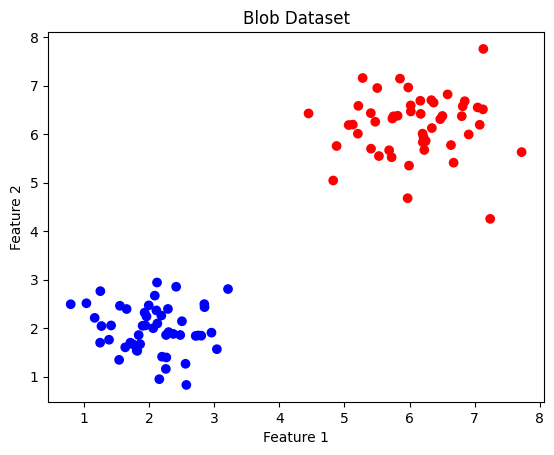

In [ ]:
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='bwr')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Blob Dataset")
plt.show()

In [ ]:
def step(z):
    return np.where(z >= 0, 1, 0)
learning_rate = 0.1
error_history =[]
for epoch in range(20):
  errors = 0
  for i in range(100):
    z_i = x[i] @ w + b
    pred_i = step(z_i)
    if(pred_i!=y[i]):
      w = w + learning_rate * (y[i] - pred_i) * x[i]
      b = b + learning_rate * (y[i] - pred_i)
      errors+=1
  if(errors==0):
    break
  error_history.append(errors)
print(error_history)

[2, 4, 4, 5, 2]


In [ ]:
error2 = 0
for i in range(100):
  z_i = x[i] @ w + b
  pred_i = step(z_i)
  if(pred_i!=y[i]):
    error2+=1
print(error2)

0


In [ ]:
x1_range = np.linspace(x[:,0].min(),x[:,0].max(),100)
x2 = (-w[0]*x1_range - b[0]) / w[1]

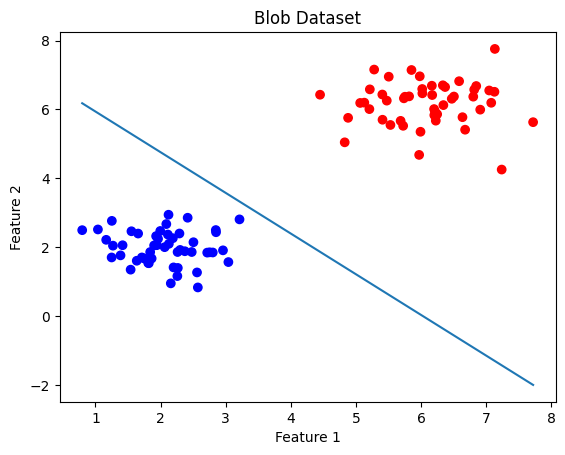

In [ ]:
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='bwr')
plt.plot(x1_range,x2)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Blob Dataset")
plt.show()

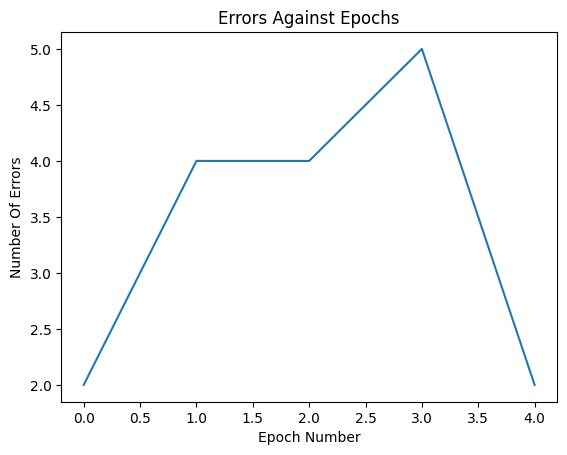

In [ ]:
plt.plot(error_history)
plt.xlabel("Epoch Number")
plt.ylabel("Number Of Errors")
plt.title("Errors Against Epochs")
plt.show()

In [ ]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [ ]:
w2 = np.zeros(2)
b2 = np.zeros(1)

In [ ]:
def compute_loss(p,y):
  loss = -(y*np.log(p) + (1-y)*np.log(1-p))
  return np.mean(loss)

In [ ]:
learning_rate = 0.1
loss_history =[]
for epoch in range(1000):
  z = x@w2 + b2
  p = sigmoid(z)
  loss_history.append(compute_loss(p,y))
  dw = (1/len(y)) * x.T @(p-y)
  db = (1/len(y)) * np.sum(p-y)
  w2 = w2 - learning_rate * dw
  b2 = b2 - learning_rate * db

In [ ]:
print(w2,b2)
print(loss_history[0])
print(loss_history[-1])

[0.58859209 0.98576303] [-5.86420351]
0.6931471805599453
0.05222124043992795


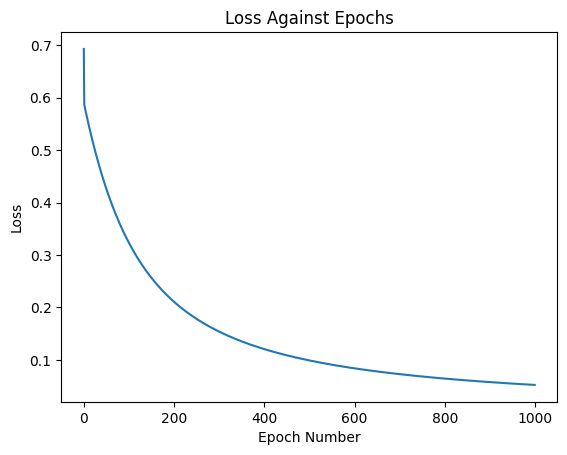

In [ ]:
plt.plot(loss_history)
plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.title("Loss Against Epochs")
plt.show()

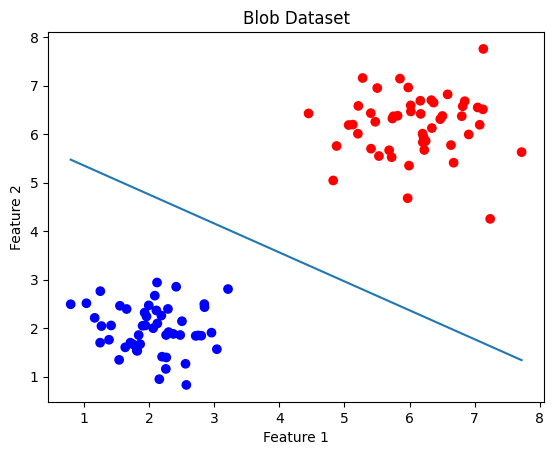

In [ ]:
x2_gd = -(w2[0]*x1_range + b2) / w2[1]
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='bwr')
plt.plot(x1_range,x2_gd)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Blob Dataset")
plt.show()

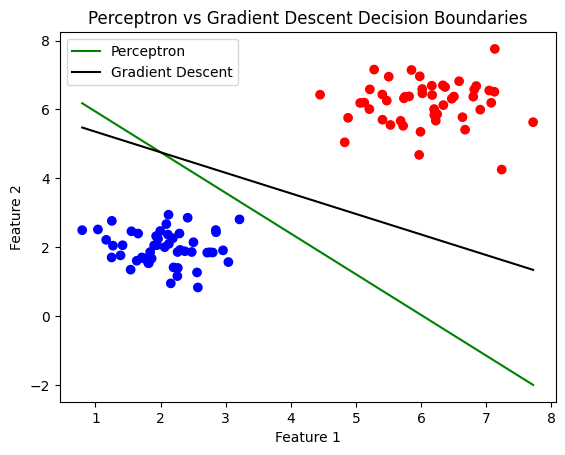

In [ ]:
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='bwr')
plt.plot(x1_range, x2, color='green', label='Perceptron')
plt.plot(x1_range, x2_gd, color='black', label='Gradient Descent')
plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title('Perceptron vs Gradient Descent Decision Boundaries')
plt.show()

In [ ]:
z = x @ w + b
predictions = step(z)
accuracy = np.mean(predictions == y)
print(accuracy)

1.0


In [ ]:
z2 = x @ w2 + b2
p2 = sigmoid(z2)
predictions2 = (p2 >= 0.5).astype(int)
accuracy2 = np.mean(predictions2 == y)
print(accuracy2)

1.0
